In [1]:
# 24.08.2026, kontynuacja - realizacja pomyslu "ujarzmienia" klastra
# granicznego 1996/2008 (patrz rozmowa + 20260824b.ipynb, gdzie policzono,
# ze po wykluczeniu konkurencji z wnetrza cyklu 1996 pozycja szczytu
# PRZESTAJE zalezec od P_days - stabilizuje sie w oknie ~3 miesiecy (d=1)
# / ~6 miesiecy (d=5) wokol listopada 2008, dla P_days 1675-4000. Zadna z
# pozostalych 4 granic tego nie robi).
#
# Realizacja dwoch punktow ustalonych w rozmowie, OBA jako czyste
# przeciecie juz policzonych danych (results/cycle_scan_*.csv +
# results/pgrid_scan_*.csv) - zero nowych zapytan NMDB/MC:
#
# A) PRZEJSCIA jako osobna, pelnoprawna kategoria: 5 nowych okien
#    wysrodkowanych na kazdej granicy cyklu (+/- TRANSITION_HALF_WIDTH_YEARS),
#    zeby klaster graniczny mial czysty "dom" zamiast rozjezdzac sie miedzy
#    dwoma sasiednimi panelami cyklowymi.
# B) PRZYCIETE wnetrza cykli: kazdy cykl przyciety o ten sam bufor przy
#    KAZDEJ granicy, ktora wspoldzieli z sasiadem (bez przyciecia na
#    zewnetrznych krancach calego zakresu danych, 1965-01-01 i 2025-01-31,
#    bo to nie sa granice miedzy dwoma naszymi cyklami). Test: czy po
#    usunieciu kontaminacji panel cyklu 2008 przestaje byc "anomalia" (boja
#    slaba regresja z 20260824a.ipynb), a panel cyklu 1996 traci podejrzana
#    gwiazdke na skraju danych (flagowana w 20260823b.ipynb).
import glob
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

RESULTS_DIR = "../results"

STATIONS_22 = ["mosc", "oulu"] + [
    s.lower() for s in [
        "THUL", "LMKS", "APTY", "SOPB", "JUNG1", "SOPO", "FSMT",
        "JUNG", "NEWK", "PWNK", "MXCO", "NAIN", "HRMS", "TERA", "INVK", "ATHN",
        "AATB", "PSNM", "NANM", "MCRL",
    ]
]
STATIONS_5 = ["mosc", "oulu", "athn", "hrms", "sopb"]

CYCLE_BOUNDS = {
    "cycle_1964": ("1965-01-01", "1976-02-01"),
    "cycle_1976": ("1976-02-01", "1986-05-01"),
    "cycle_1986": ("1986-05-01", "1996-06-01"),
    "cycle_1996": ("1996-06-01", "2008-11-01"),
    "cycle_2008": ("2008-11-01", "2019-09-01"),
    "cycle_2019_incomplete": ("2019-09-01", "2025-01-31"),
}
CYCLE_ORDER = list(CYCLE_BOUNDS)
CYCLE_START = {c: pd.Timestamp(s) for c, (s, e) in CYCLE_BOUNDS.items()}
CYCLE_END = {c: pd.Timestamp(e) for c, (s, e) in CYCLE_BOUNDS.items()}
TRANSITIONS = [(CYCLE_ORDER[i], CYCLE_ORDER[i + 1]) for i in range(len(CYCLE_ORDER) - 1)]

P_DAYS_5_GRID = [1675, 2100, 2515, 2930, 3350, 3600, 3800, 4000]
P_DAYS_22_GRID = [1675, 3350]

# Szerokosc bufora - dobrana na podstawie tego, co realnie zaobserwowano w
# 20260824b.ipynb (klaster graniczny 1996/2008 pinowal sie w oknie
# ~3-6 miesiecy wokol granicy po wykluczeniu konkurencji) - 2 lata to
# bezpieczny margines z zapasem, wciaz nie zjadajacy calych "normalnych"
# wewnetrznych wzniesien sasiednich cykli (te siedza 1.5-6 lat OD WLASNEGO
# startu, wiec przyciecie 2 lat od granicy ucina ich najblizszy skraj, nie
# cala strukture). Latwo zmienic i sprawdzic wrazliwosc na ta wartosc.
TRANSITION_HALF_WIDTH_YEARS = 2.0
TRANSITION_HALF_WIDTH = pd.Timedelta(days=round(TRANSITION_HALF_WIDTH_YEARS * 365.25))
print(f"Bufor przejscia: +/- {TRANSITION_HALF_WIDTH_YEARS} lat = {TRANSITION_HALF_WIDTH}")

Bufor przejscia: +/- 2.0 lat = 730 days 00:00:00


In [2]:
# Wczytanie danych - identyczne zrodlo co 20260824a/b.ipynb: 5 stacji x 8
# wartosci P_days (cycle_scan_* + pgrid_scan_*) i 22 stacje x P_days w
# {1675, 3350} (cycle_scan_* only).
FILENAME_RE_5 = re.compile(
    r"^(?P<prefix>cycle_scan|pgrid_scan)_(?P<station>[a-z]+)_(?P<cycle>cycle_\d{4}(?:_incomplete)?)_P(?P<Pdays>\d+)_d(?P<d>\d+)\.csv$"
)


def parse_5(path):
    m = FILENAME_RE_5.match(os.path.basename(path))
    if not m or m["station"] not in STATIONS_5 or m["cycle"] not in CYCLE_BOUNDS:
        return None
    return dict(station=m["station"], cycle=m["cycle"], P_days=int(m["Pdays"]), d=int(m["d"]))


frames_5 = []
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, "cycle_scan_*.csv")) +
                    glob.glob(os.path.join(RESULTS_DIR, "pgrid_scan_*.csv"))):
    meta = parse_5(path)
    if meta is None:
        continue
    df = pd.read_csv(path, usecols=["t0", "PPDF"], parse_dates=["t0"]).dropna(subset=["PPDF"])
    if len(df) == 0:
        continue
    df["station"] = meta["station"]
    df["cycle"] = meta["cycle"]
    df["P_days"] = meta["P_days"]
    df["d"] = meta["d"]
    frames_5.append(df)

all_candidates_5 = pd.concat(frames_5, ignore_index=True)
print(f"5 stacji: wczytano {len(all_candidates_5)} wierszy z {len(frames_5)} plikow")

FILENAME_RE_22 = re.compile(
    r"^cycle_scan_(?P<station>[a-z0-9]+)_(?P<cycle>cycle_\d{4}(?:_incomplete)?)_P(?P<Pdays>\d+)_d(?P<d>\d+)\.csv$"
)


def parse_22(path):
    m = FILENAME_RE_22.match(os.path.basename(path))
    if not m or int(m["Pdays"]) not in P_DAYS_22_GRID or m["cycle"] not in CYCLE_BOUNDS:
        return None
    return dict(station=m["station"], cycle=m["cycle"], P_days=int(m["Pdays"]), d=int(m["d"]))


frames_22 = []
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, "cycle_scan_*.csv"))):
    meta = parse_22(path)
    if meta is None:
        continue
    df = pd.read_csv(path, usecols=["t0", "PPDF"], parse_dates=["t0"]).dropna(subset=["PPDF"])
    if len(df) == 0:
        continue
    df["station"] = meta["station"]
    df["cycle"] = meta["cycle"]
    df["P_days"] = meta["P_days"]
    df["d"] = meta["d"]
    frames_22.append(df)

all_candidates_22 = pd.concat(frames_22, ignore_index=True)
print(f"22 stacje: wczytano {len(all_candidates_22)} wierszy z {len(frames_22)} plikow")

5 stacji: wczytano 1196172 wierszy z 344 plikow
22 stacje: wczytano 1206908 wierszy z 384 plikow


In [3]:
# Definicje dwoch nowych podzialow - OBA jako proste (start, koniec, opcjonalna
# data-do-zaznaczenia) okna kalendarzowe, budowane wylacznie z juz zdefiniowanych
# CYCLE_BOUNDS + TRANSITION_HALF_WIDTH. Kandydaci sa potem wybierani z
# all_candidates_5/22 bezposrednio po dacie t0 (nie po kolumnie "cycle") - to
# dziala poprawnie, bo pliki cycle_scan_*/pgrid_scan_* razem pokrywaja cala
# os czasu 1965-2025 bez dziur/nakladania (kazdy kandydat nalezy do
# dokladnie jednego pliku zrodlowego), wiec filtrowanie po samej dacie jest
# rownowazne wyborowi odpowiednich plikow, ale prostsze i dziala identycznie
# dla obu kategorii ponizej.

# A) PRZEJSCIA: 5 okien wysrodkowanych na kazdej granicy.
TRANSITION_WINDOWS = {}
for a, b in TRANSITIONS:
    boundary = CYCLE_END[a]
    name = f"transition_{boundary.year}"
    TRANSITION_WINDOWS[name] = (boundary - TRANSITION_HALF_WIDTH, boundary + TRANSITION_HALF_WIDTH, boundary)

# B) PRZYCIETE WNETRZA CYKLI: kazdy cykl przyciety o TRANSITION_HALF_WIDTH przy
# KAZDEJ granicy dzielonej z sasiadem (nie na zewnetrznych krancach calego
# zakresu danych - 1965-01-01 i 2025-01-31 to nie sa granice miedzy naszymi
# cyklami).
TRIMMED_CYCLE_WINDOWS = {}
for i, c in enumerate(CYCLE_ORDER):
    left_trim = TRANSITION_HALF_WIDTH if i > 0 else pd.Timedelta(0)
    right_trim = TRANSITION_HALF_WIDTH if i < len(CYCLE_ORDER) - 1 else pd.Timedelta(0)
    TRIMMED_CYCLE_WINDOWS[c] = (CYCLE_START[c] + left_trim, CYCLE_END[c] - right_trim, None)

print("Okna przejsciowe:")
for name, (s, e, b) in TRANSITION_WINDOWS.items():
    print(f"  {name}: {s.date()} .. {e.date()} (granica {b.date()})")
print("\nPrzyciete wnetrza cykli:")
for name, (s, e, b) in TRIMMED_CYCLE_WINDOWS.items():
    print(f"  {name}: {s.date()} .. {e.date()} ({(e-s).days/365.25:.2f} lat)")

Okna przejsciowe:
  transition_1976: 1974-02-01 .. 1978-01-31 (granica 1976-02-01)
  transition_1986: 1984-05-01 .. 1988-04-30 (granica 1986-05-01)
  transition_1996: 1994-06-02 .. 1998-06-01 (granica 1996-06-01)
  transition_2008: 2006-11-02 .. 2010-11-01 (granica 2008-11-01)
  transition_2019: 2017-09-01 .. 2021-08-31 (granica 2019-09-01)

Przyciete wnetrza cykli:
  cycle_1964: 1965-01-01 .. 1974-02-01 (9.08 lat)
  cycle_1976: 1978-01-31 .. 1984-05-01 (6.25 lat)
  cycle_1986: 1988-04-30 .. 1994-06-02 (6.09 lat)
  cycle_1996: 1998-06-01 .. 2006-11-02 (8.42 lat)
  cycle_2008: 2010-11-01 .. 2017-09-01 (6.83 lat)
  cycle_2019_incomplete: 2021-08-31 .. 2025-01-31 (3.42 lat)


In [4]:
# Funkcje wspolne dla obu kategorii okien - budowa macierzy [P_days x
# lata-od-startu-okna] mediana -log10(PPDF) po dostepnych stacjach +
# pozycja/wartosc lokalnego maksimum per wiersz P_days, oraz rysowanie
# siatki paneli (jeden okno = jeden panel), z opcjonalnym oznaczeniem
# granicy pionowa linia.
def build_window_heatmap(start, end, data, p_days_list, d):
    sub_all = data[(data["d"] == d) & (data["t0"] >= start) & (data["t0"] < end)]
    t0_ref = pd.date_range(start, end, freq="24h")
    available_p = [p for p in p_days_list if p in sub_all["P_days"].unique()]
    mat = np.full((len(available_p), len(t0_ref)), np.nan)
    peaks = []
    for i, P_days in enumerate(available_p):
        sub = sub_all[sub_all["P_days"] == P_days]
        med_ppdf = sub.groupby("t0")["PPDF"].median().reindex(t0_ref)
        with np.errstate(divide="ignore"):
            mat[i] = -np.log10(np.clip(med_ppdf.to_numpy(dtype=float), 1e-300, None))
        if np.isfinite(mat[i]).any():
            ti = np.nanargmax(mat[i])
            peaks.append(dict(P_days=P_days, t0=t0_ref[ti], neglog10_ppdf=mat[i][ti]))
    return t0_ref, available_p, mat, pd.DataFrame(peaks)


def plot_windows(windows, data, p_days_list, d, station_label, save_suffix, mark_boundary):
    names = list(windows)
    fig, axes = plt.subplots(len(names), 1, figsize=(12, 3.2 * len(names)))
    if len(names) == 1:
        axes = [axes]
    results = {name: build_window_heatmap(*windows[name][:2], data, p_days_list, d) for name in names}

    vmax = 0.0
    for t0_ref, available_p, mat, peaks in results.values():
        if np.isfinite(mat).any():
            vmax = max(vmax, np.nanmax(mat))

    im = None
    for ax, name in zip(axes, names):
        start, end, boundary = windows[name]
        t0_ref, available_p, mat, peaks = results[name]
        if len(available_p) == 0:
            ax.set_visible(False)
            continue
        years = (t0_ref - start).days / 365.25
        im = ax.imshow(
            mat, aspect="auto", cmap="viridis", vmin=0, vmax=vmax,
            extent=[years.min(), years.max(), len(available_p) - 0.5, -0.5],
        )
        ax.set_yticks(range(len(available_p)))
        ax.set_yticklabels(available_p)
        ax.set_ylim(len(available_p) - 0.5, -0.5)
        if mark_boundary and boundary is not None:
            ax.axvline((boundary - start).days / 365.25, color="red", ls="--", lw=1.5)
        if len(peaks):
            peak_years = (peaks["t0"] - start).dt.days / 365.25
            row_of = {p: i for i, p in enumerate(available_p)}
            ax.scatter(peak_years, peaks["P_days"].map(row_of), s=40, color="white",
                       edgecolor="black", linewidth=0.6, zorder=5)
        span_y = (end - start).days / 365.25
        ax.set_title(f"{name} ({start.date()}..{end.date()}, {span_y:.1f}y)", fontsize=9)
        ax.set_ylabel("P_days")
    axes[-1].set_xlabel("lata od poczatku okna")
    if im is not None:
        fig.colorbar(im, ax=axes, label=f"mediana -log10(PPDF) ({station_label})", shrink=0.7)
    fig.suptitle(f"{save_suffix} (d={d}, {station_label})", fontsize=13)
    fig.savefig(f"{RESULTS_DIR}/{save_suffix}.png", dpi=120, bbox_inches="tight")
    plt.show()
    return results

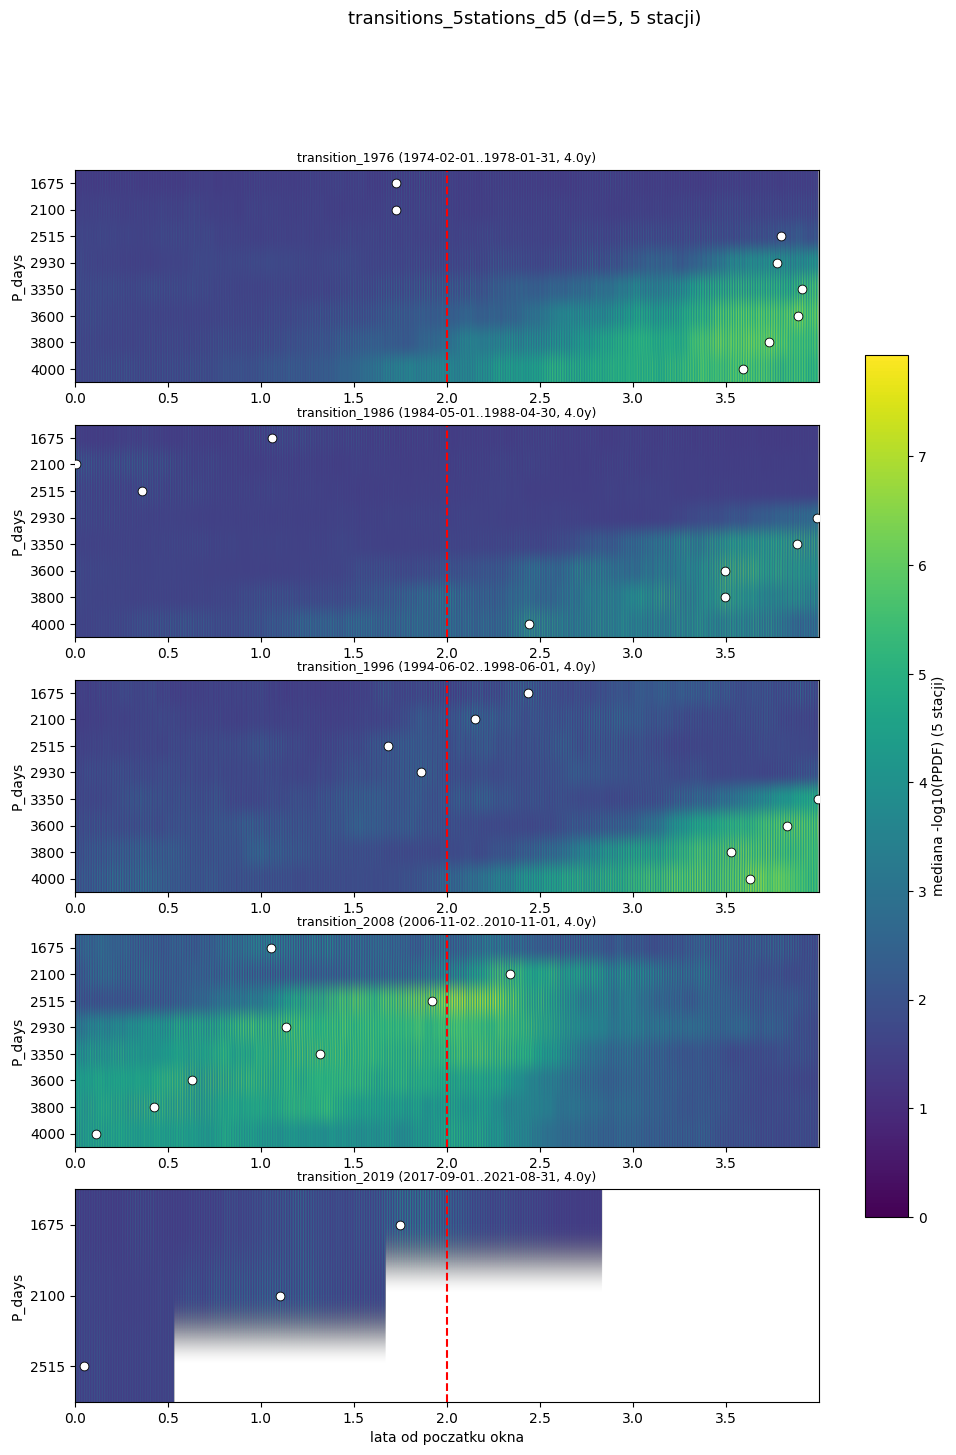

In [5]:
# CZESC A: okna przejsciowe - "czysty" widok kazdej granicy w izolacji
# (+/- 2 lata), bez konkurencji z odleglymi wnetrzami cykli. Jesli 1996/2008
# rzeczywiscie sie wyroznia, jego panel powinien pokazac SILNY, SPOJNY
# (male przemieszczenie miedzy wierszami P_days) sygnal blisko czerwonej
# linii, podczas gdy pozostale 4 panele powinny wygladac plasko/bez wyraznej
# struktury (bo tam - jak juz sprawdzono w 20260824b.ipynb - nie ma nic
# przy samej granicy, tylko odlegle skrzydla sasiednich "normalnych"
# wzniesien, ktore w tym waskim oknie +/-2 lata w duzej mierze nie miesza sie).
transitions_5st_d5 = plot_windows(TRANSITION_WINDOWS, all_candidates_5, P_DAYS_5_GRID, 5,
                                   "5 stacji", "transitions_5stations_d5", mark_boundary=True)

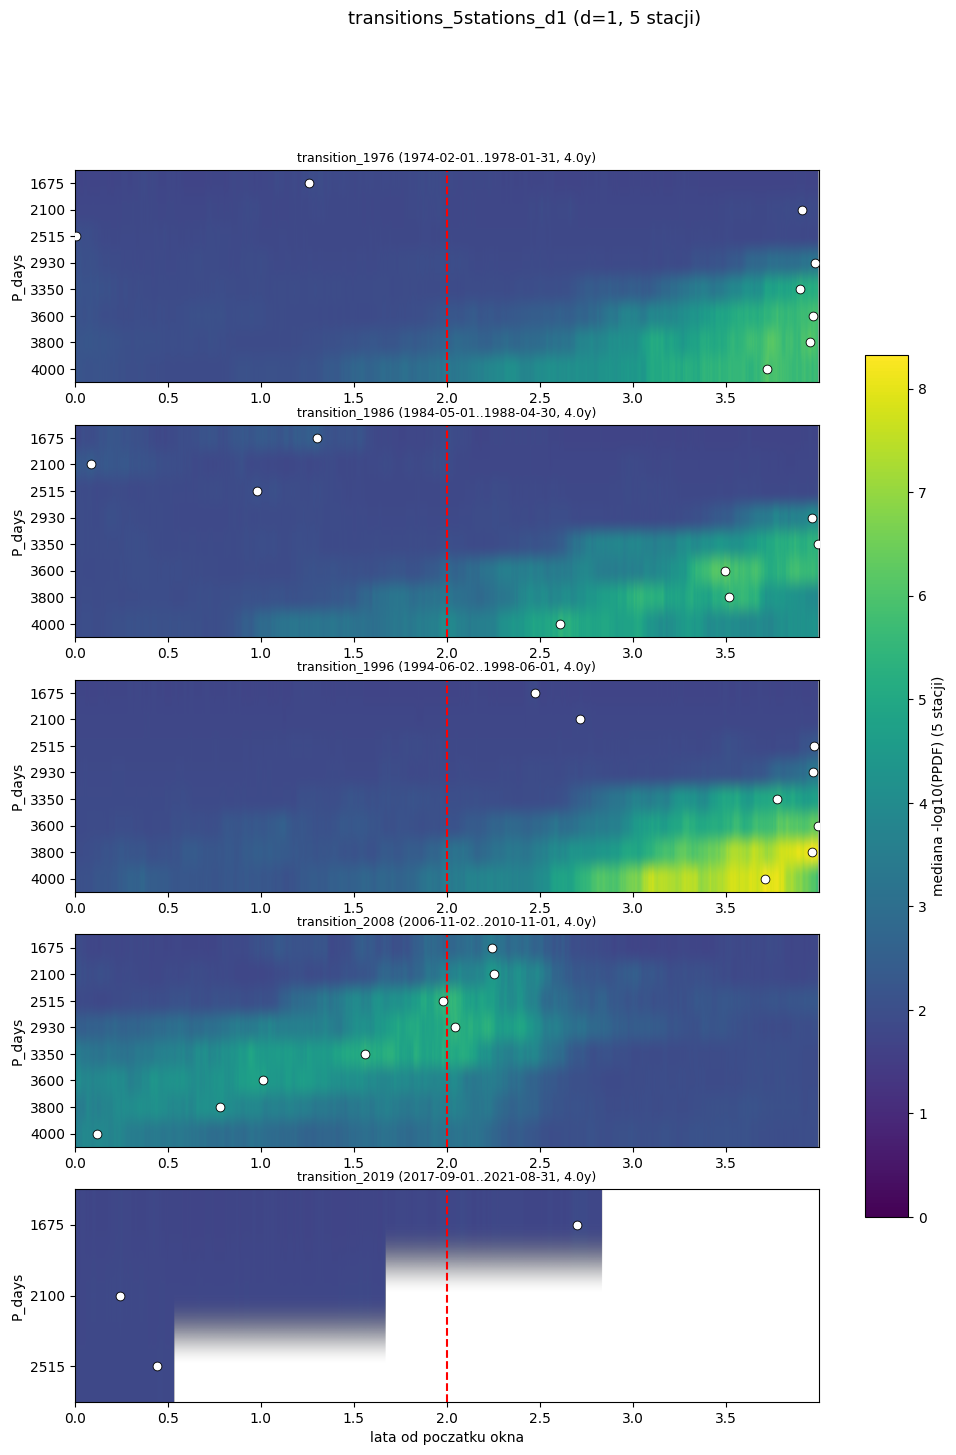

In [6]:
transitions_5st_d1 = plot_windows(TRANSITION_WINDOWS, all_candidates_5, P_DAYS_5_GRID, 1,
                                   "5 stacji", "transitions_5stations_d1", mark_boundary=True)

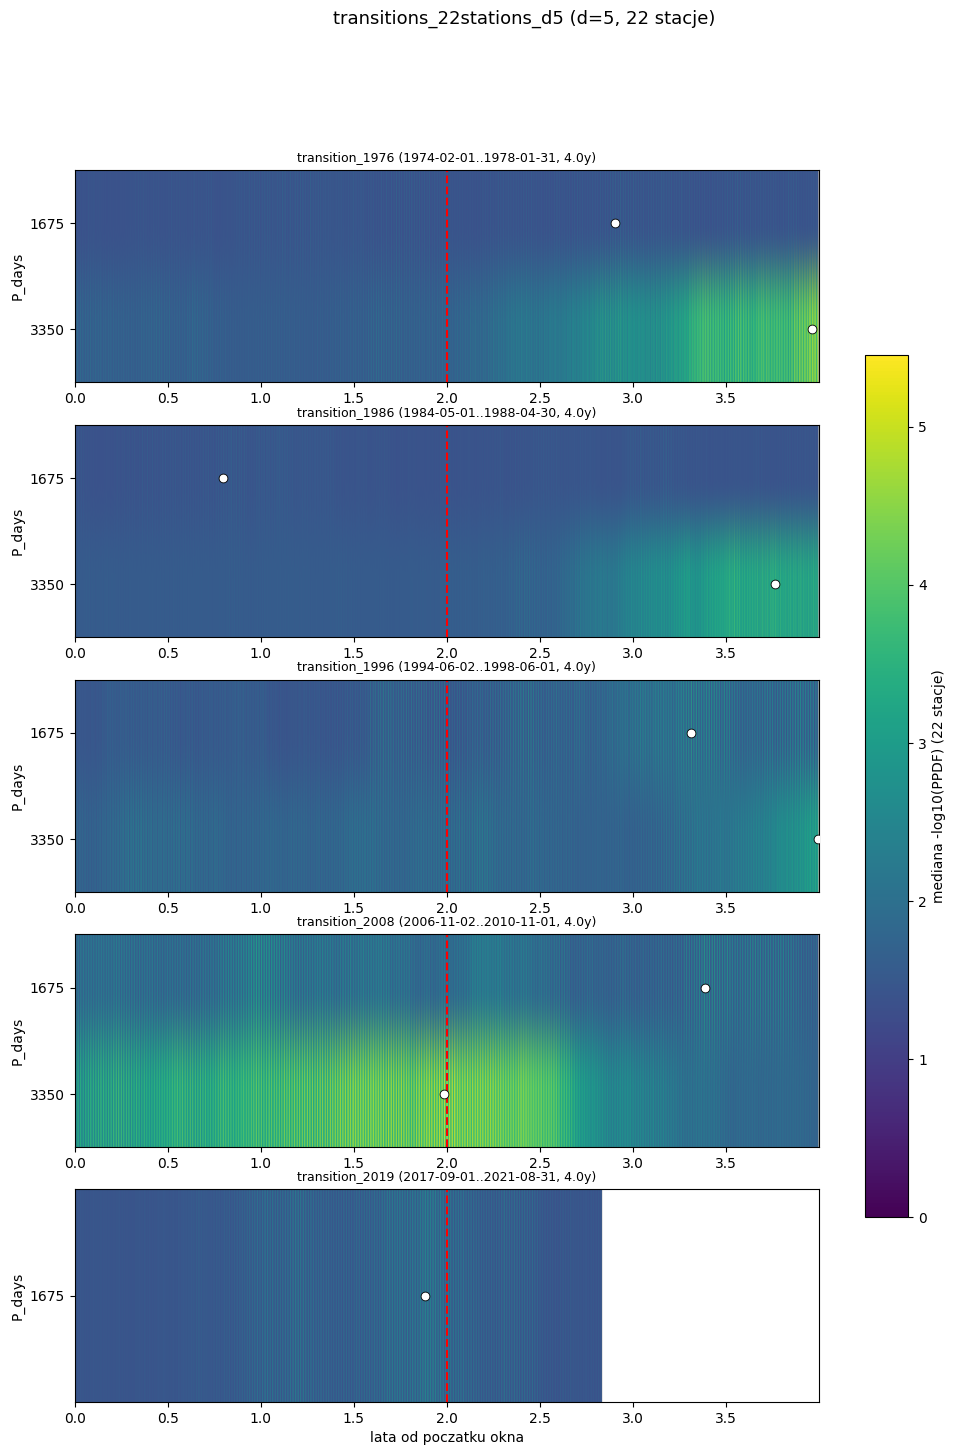

In [7]:
transitions_22st_d5 = plot_windows(TRANSITION_WINDOWS, all_candidates_22, P_DAYS_22_GRID, 5,
                                    "22 stacje", "transitions_22stations_d5", mark_boundary=True)

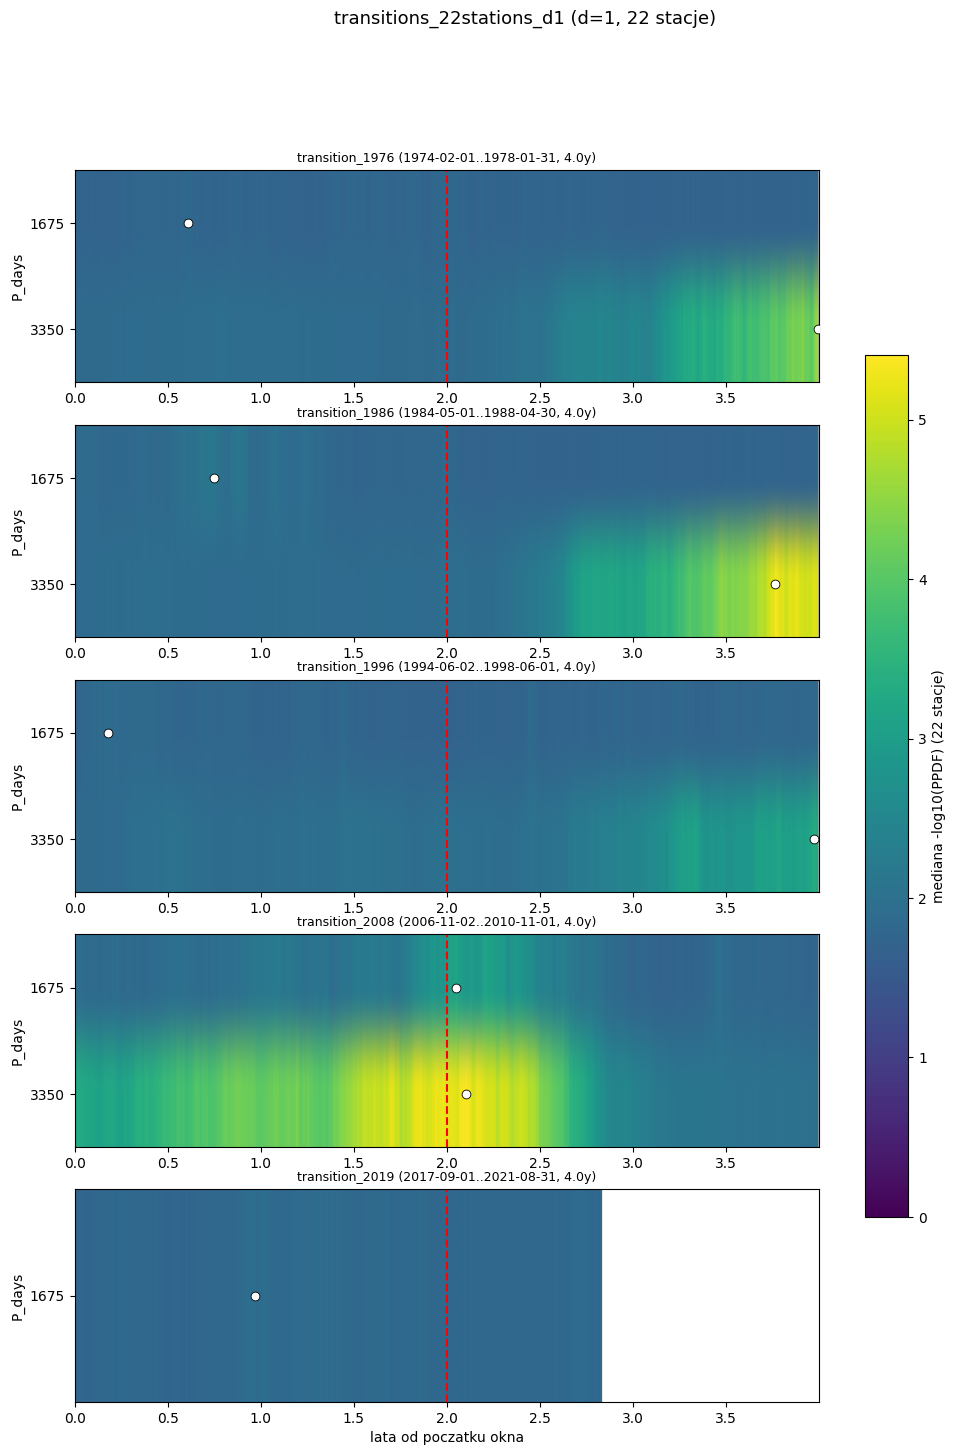

In [8]:
transitions_22st_d1 = plot_windows(TRANSITION_WINDOWS, all_candidates_22, P_DAYS_22_GRID, 1,
                                    "22 stacje", "transitions_22stations_d1", mark_boundary=True)

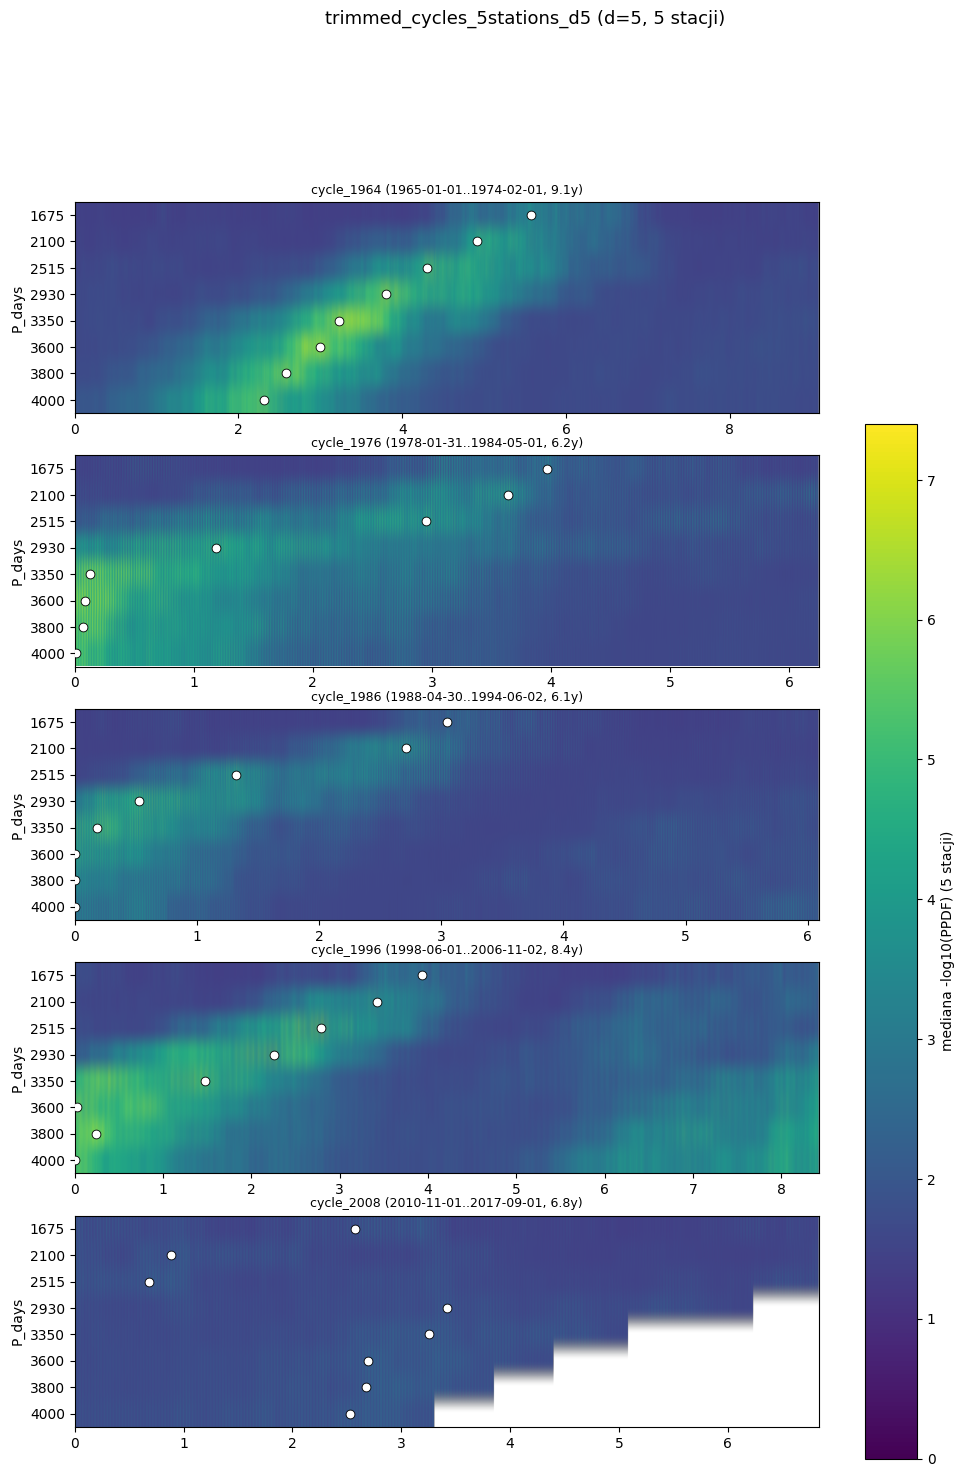

In [9]:
# CZESC B: przyciete wnetrza cykli - test, czy usuniecie bufora granicznego
# NAPRAWIA dwa konkretne problemy sprzed dzisiejszej dyskusji: (1) podejrzana
# gwiazdka na skraju danych w panelu cyklu 1996 (20260823b.ipynb, t=12.3
# roku) powinna zniknac (bo lezala w wlasnie wycietym buforze); (2) panel
# cyklu 2008 - dotychczas "kliff+plateau" (20260824a.ipynb Czesc B) -
# powinien teraz wygladac PLASKO/NIJAKO (bez zadnej struktury), jesli caly
# ten sygnal byl w istocie wlasnoscia GRANICY, nie wnetrza cyklu 2008 jako
# takiego.
trimmed_5st_d5 = plot_windows(TRIMMED_CYCLE_WINDOWS, all_candidates_5, P_DAYS_5_GRID, 5,
                               "5 stacji", "trimmed_cycles_5stations_d5", mark_boundary=False)

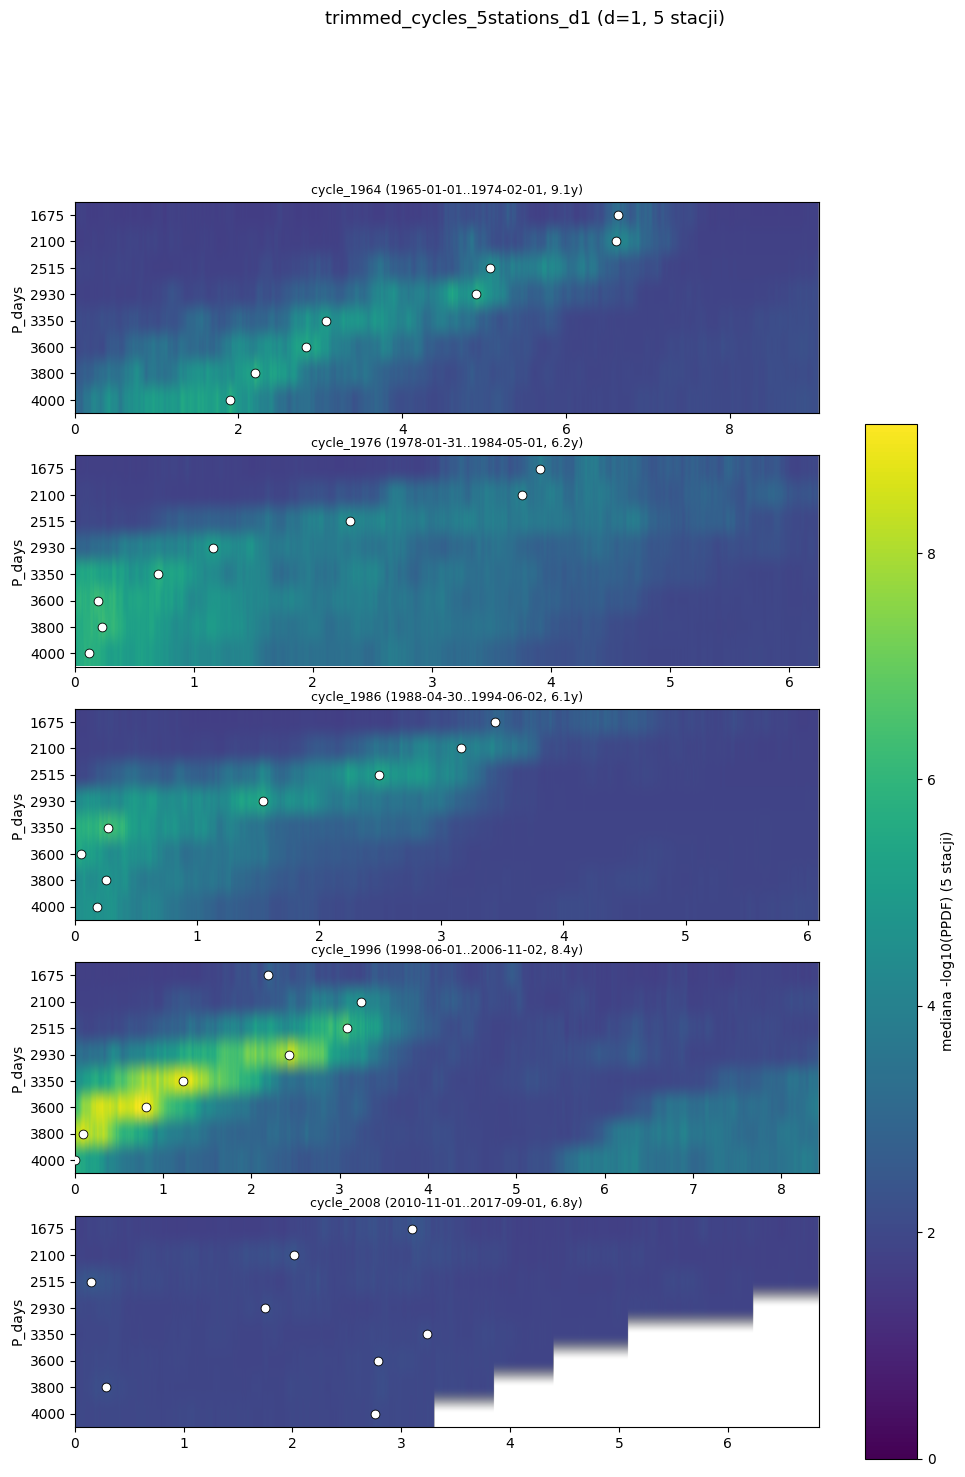

In [10]:
trimmed_5st_d1 = plot_windows(TRIMMED_CYCLE_WINDOWS, all_candidates_5, P_DAYS_5_GRID, 1,
                               "5 stacji", "trimmed_cycles_5stations_d1", mark_boundary=False)

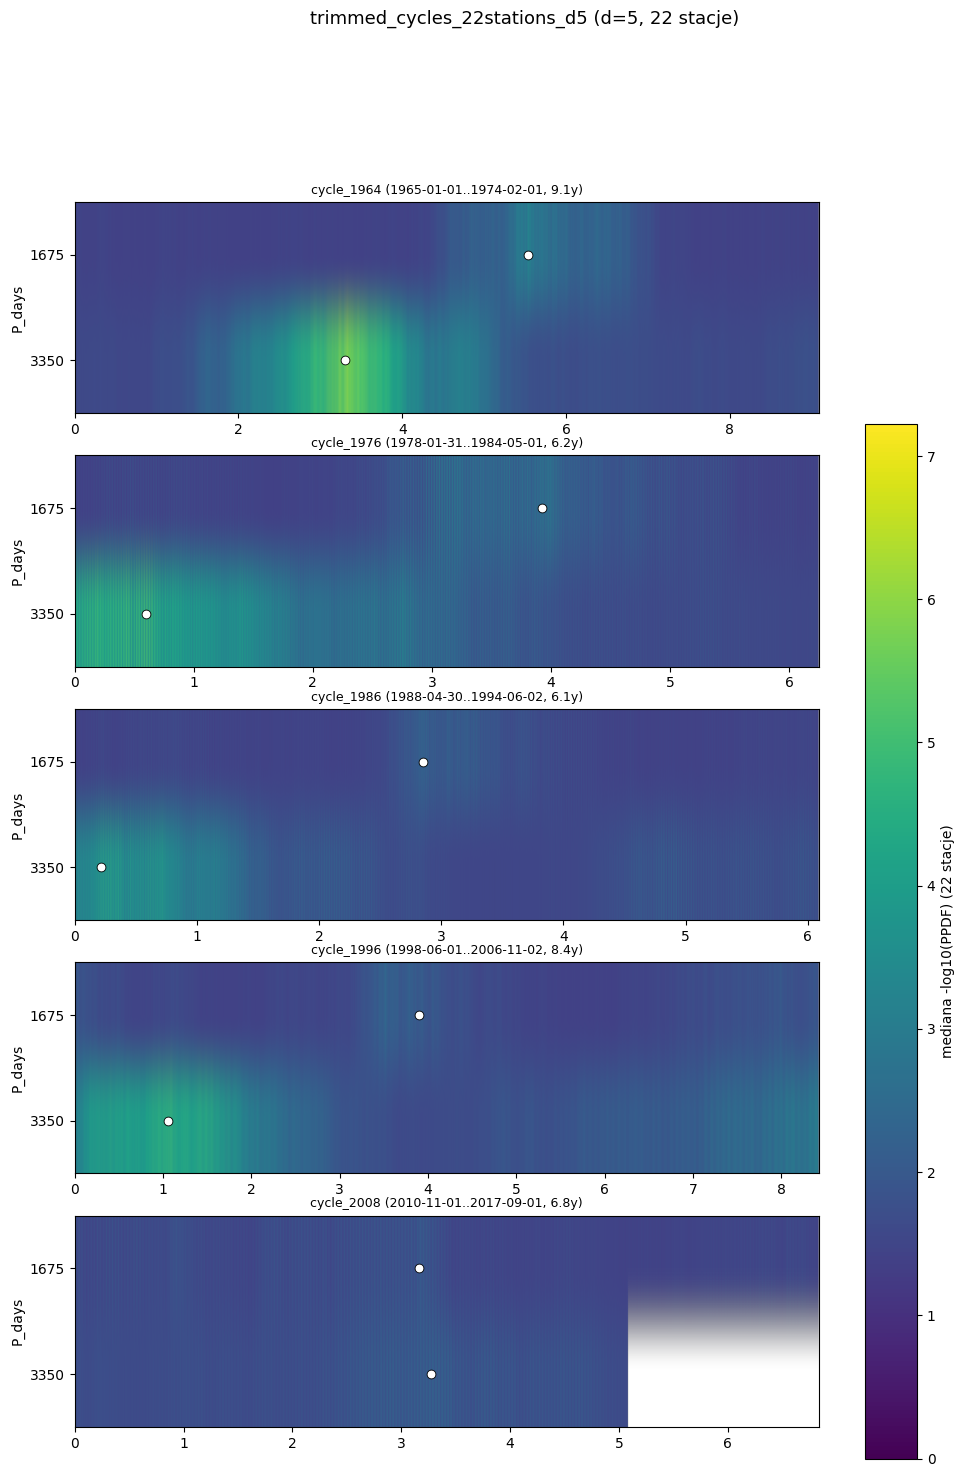

In [11]:
trimmed_22st_d5 = plot_windows(TRIMMED_CYCLE_WINDOWS, all_candidates_22, P_DAYS_22_GRID, 5,
                                "22 stacje", "trimmed_cycles_22stations_d5", mark_boundary=False)

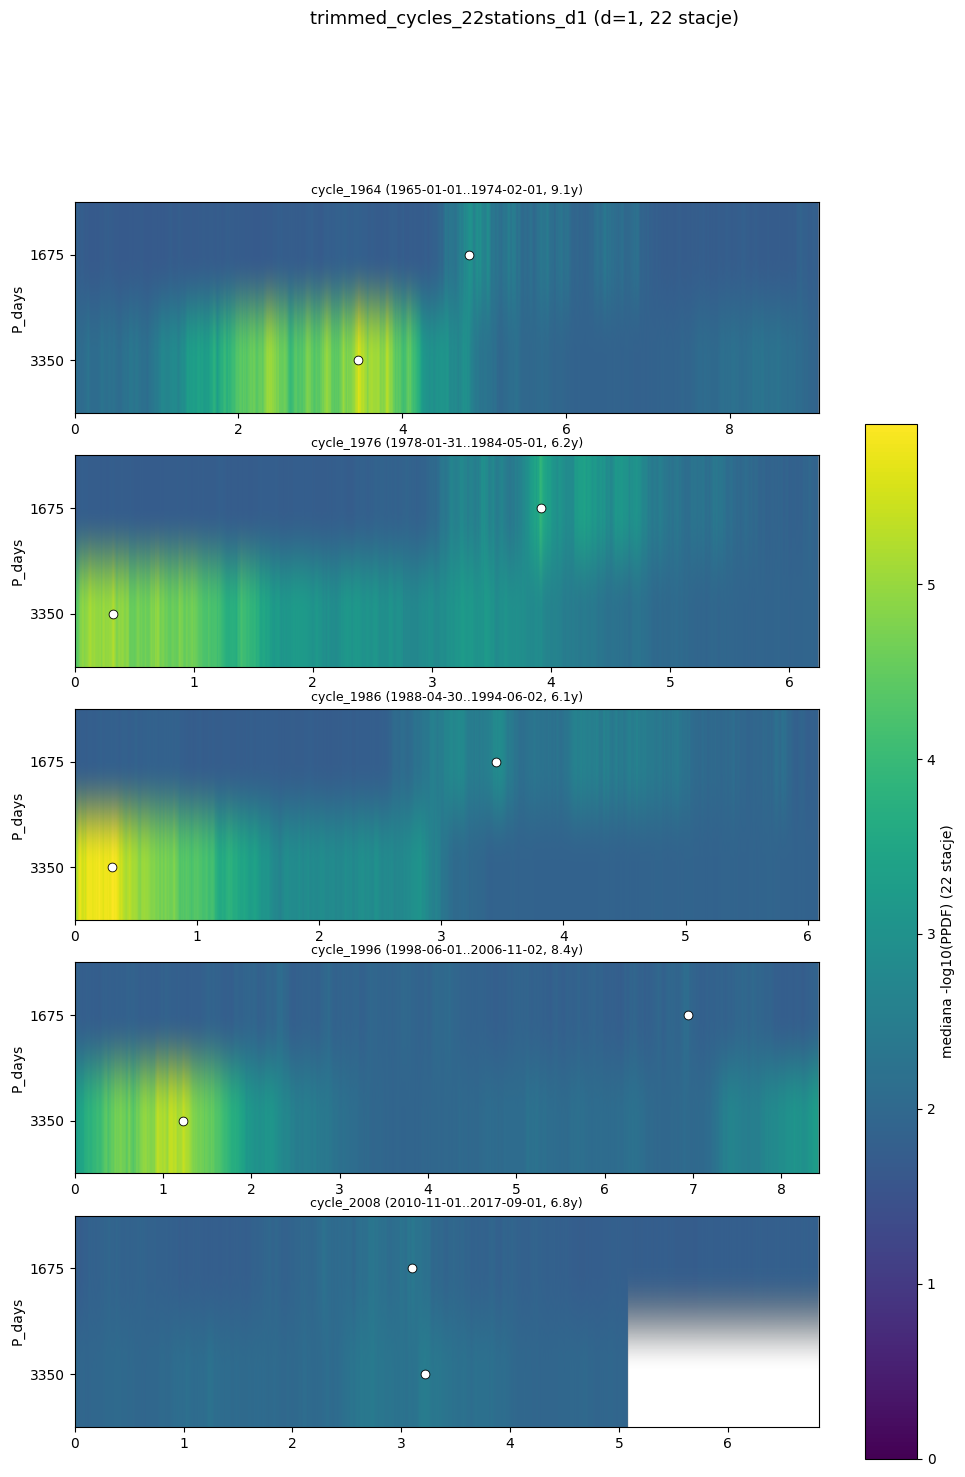

In [12]:
trimmed_22st_d1 = plot_windows(TRIMMED_CYCLE_WINDOWS, all_candidates_22, P_DAYS_22_GRID, 1,
                                "22 stacje", "trimmed_cycles_22stations_d1", mark_boundary=False)

In [13]:
# Regresja (jak w 20260824a.ipynb Czesc B), ale na PRZYCIETYCH oknach
# cyklowych - kluczowy test: czy dopasowanie liniowe dla cyklu 2008 poprawia
# sie po usunieciu kontaminacji klastrem granicznym (tam bylo: d=1 r=-0.80,
# d=5 r=-0.66/p=0.078 nieistotne - wyraznie slabsze/mniej spojne niz
# pozostale cykle).
MIN_POINTS_FOR_FIT = 4

trimmed_fit_rows = []
for d in (1, 5):
    for name, (start, end, boundary) in TRIMMED_CYCLE_WINDOWS.items():
        t0_ref, available_p, mat, peaks = build_window_heatmap(start, end, all_candidates_5, P_DAYS_5_GRID, d)
        if len(peaks) < MIN_POINTS_FOR_FIT:
            trimmed_fit_rows.append(dict(cycle=name, d=d, n_points=len(peaks),
                                          slope_years_per_1000d=np.nan, r_value=np.nan, p_value=np.nan))
            continue
        years = (peaks["t0"] - start).dt.days / 365.25
        fit = linregress(peaks["P_days"], years)
        trimmed_fit_rows.append(dict(cycle=name, d=d, n_points=len(peaks),
                                      slope_years_per_1000d=fit.slope * 1000,
                                      r_value=fit.rvalue, p_value=fit.pvalue))

trimmed_fit_summary = pd.DataFrame(trimmed_fit_rows).sort_values(["d", "cycle"])
pd.set_option("display.width", 160)
print(trimmed_fit_summary.to_string(index=False))
trimmed_fit_summary.to_csv(f"{RESULTS_DIR}/trimmed_cycle_ridge_fit.csv", index=False)

                cycle  d  n_points  slope_years_per_1000d   r_value      p_value
           cycle_1964  1         8              -2.227391 -0.981669 1.518765e-05
           cycle_1976  1         8              -1.835844 -0.974186 4.217329e-05
           cycle_1986  1         8              -1.657101 -0.970649 6.183064e-05
           cycle_1996  1         8              -1.309355 -0.856002 6.681734e-03
           cycle_2008  1         8              -0.052698 -0.036343 9.319175e-01
cycle_2019_incomplete  1         0                    NaN       NaN          NaN
           cycle_1964  5         8              -1.366400 -0.998894 3.377422e-09
           cycle_1976  5         8              -1.994323 -0.966819 8.907282e-05
           cycle_1986  5         8              -1.429263 -0.953981 2.353057e-04
           cycle_1996  5         8              -1.830458 -0.977797 2.691003e-05
           cycle_2008  5         8               0.553010  0.457688 2.541487e-01
cycle_2019_incomplete  5    

In [14]:
# Podsumowanie sily/spojnosci klastra granicznego per przejscie (5 granic x
# 2 zestawy stacji x d=1/5) - male "peak_t0_spread_days" (rozpietosc dat
# szczytu miedzy roznymi P_days) = klaster "przyklejony" do granicy
# niezaleznie od P_days (podejrzane, jak 1996/2008 w 20260824b.ipynb);
# duze/nieregularne = granica bez szczegolnego znaczenia.
transition_rows = []
for label, data, p_list in [("5stations", all_candidates_5, P_DAYS_5_GRID),
                             ("22stations", all_candidates_22, P_DAYS_22_GRID)]:
    for d in (1, 5):
        for name, (start, end, boundary) in TRANSITION_WINDOWS.items():
            t0_ref, available_p, mat, peaks = build_window_heatmap(start, end, data, p_list, d)
            if len(peaks) == 0:
                continue
            transition_rows.append(dict(
                transition=name, stations=label, d=d, n_Pdays=len(peaks),
                strongest_neglog10_ppdf=peaks["neglog10_ppdf"].max(),
                peak_t0_spread_days=(peaks["t0"].max() - peaks["t0"].min()).days,
                median_peak_t0=peaks["t0"].median(),
            ))

transition_strength_summary = pd.DataFrame(transition_rows).sort_values(["stations", "d", "transition"])
print(transition_strength_summary.to_string(index=False))
transition_strength_summary.to_csv(f"{RESULTS_DIR}/transition_strength_summary.csv", index=False)

     transition   stations  d  n_Pdays  strongest_neglog10_ppdf  peak_t0_spread_days      median_peak_t0
transition_1976 22stations  1        2                 4.633626                 1236 1976-05-21 00:00:00
transition_1986 22stations  1        2                 5.386367                 1101 1986-08-03 12:00:00
transition_1996 22stations  1        2                 3.354970                 1386 1996-06-29 00:00:00
transition_2008 22stations  1        2                 5.407976                   20 2008-11-29 00:00:00
transition_2019 22stations  1        1                 1.960982                    0 2018-08-21 00:00:00
transition_1976 22stations  5        2                 4.867527                  386 1977-07-09 00:00:00
transition_1986 22stations  5        2                 3.865299                 1083 1986-08-12 12:00:00
transition_1996 22stations  5        2                 3.670960                  249 1998-01-26 12:00:00
transition_2008 22stations  5        2                 